# Ingeniería de datos e integración inicial

Este notebook documenta la transformación reproducible de transacciones aisladas
en secuencias temporales listas para modelos de deep learning. El flujo comienza
comparando los datasets reales indicados en el proyecto, toma decisiones a partir
del EDA, construye splits por remitente y termina con pruebas sobre los archivos
guardados.

In [1]:
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
    print("Dependencias instaladas en Colab")
else:
    print("Entorno local: dependencias existentes")

Entorno local: dependencias existentes


In [2]:
import json, os, pickle, time
from pathlib import Path
import kagglehub, numpy as np, pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
assert (ROOT / "src").exists(), "Ejecutar desde la raíz del repositorio"
os.environ.setdefault("KAGGLEHUB_CACHE", str(ROOT / ".kagglehub"))
ARTIFACTS, FIGURES = ROOT / "artifacts", ROOT / "reports" / "figures"
ARTIFACTS.mkdir(exist_ok=True); FIGURES.mkdir(parents=True, exist_ok=True)
start = time.perf_counter()
print("Raíz:", ROOT)

C:\Projects\Deep-Learning\.runtime\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raíz: C:\Projects\Deep-Learning


## 1. Datos reales y decisión PaySim vs IBM AML

PaySim se evalúa primero. Se descarta únicamente si las métricas reales muestran
que no puede representar comportamiento histórico por remitente.

In [3]:
paysim_dir = Path(kagglehub.dataset_download("ealaxi/paysim1"))
paysim_csv = next(paysim_dir.glob("*.csv"))
ibm_csv = Path(kagglehub.dataset_download(
    "ealtman2019/ibm-transactions-for-anti-money-laundering-aml",
    path="HI-Small_Trans.csv",
))

from scripts.audit_datasets import audit_ibm, audit_paysim
audit_dir = ARTIFACTS / "audit"; audit_dir.mkdir(parents=True, exist_ok=True)
audit_path = audit_dir / "dataset_audit.json"
ibm_summary_path = audit_dir / "ibm_sender_summary.csv.gz"
paysim_summary_path = audit_dir / "paysim_sender_summary.csv.gz"
if audit_path.exists() and ibm_summary_path.exists() and paysim_summary_path.exists():
    audit = json.loads(audit_path.read_text(encoding="utf-8"))
    print("Auditoría completa reutilizada")
else:
    paysim_audit, paysim_senders = audit_paysim(paysim_csv)
    ibm_audit, ibm_senders = audit_ibm(ibm_csv)
    audit = {"paysim": paysim_audit, "ibm_aml": ibm_audit}
    audit_path.write_text(json.dumps(audit, indent=2), encoding="utf-8")
    paysim_senders.to_csv(paysim_summary_path, index=False, compression="gzip")
    ibm_senders.to_csv(ibm_summary_path, index=False, compression="gzip")
display(pd.DataFrame({
    "dataset": ["PaySim", "IBM AML HI-Small"],
    "filas": [audit["paysim"]["rows"], audit["ibm_aml"]["rows"]],
    "remitentes": [audit["paysim"]["senders"], audit["ibm_aml"]["senders"]],
    "p99_tx_remitente": [audit["paysim"]["transactions_per_sender"]["p99"], audit["ibm_aml"]["transactions_per_sender"]["p99"]],
    "apto_para_secuencias": [audit["paysim"]["suitable_for_sender_sequences"], audit["ibm_aml"]["suitable_for_sender_sequences"]],
}))
print(json.dumps(audit, indent=2))

Auditoría completa reutilizada


,dataset,filas,remitentes,p99_tx_remitente,apto_para_secuencias
0,PaySim,6362620,6353307,1.0,False
1,IBM AML HI-Small,5078345,496999,92.0,True


{
  "paysim": {
    "dataset": "PaySim",
    "rows": 6362620,
    "positive_transactions": 8213,
    "senders": 6353307,
    "positive_senders": 8213,
    "transactions_per_sender": {
      "mean": 1.0014658507766112,
      "median": 1.0,
      "p90": 1.0,
      "p95": 1.0,
      "p99": 1.0,
      "max": 3
    },
    "senders_ge_2": 9298,
    "senders_ge_3": 15,
    "senders_ge_4": 0,
    "positive_senders_ge_2": 28,
    "positive_senders_ge_3": 0,
    "suitable_for_sender_sequences": false
  },
  "ibm_aml": {
    "dataset": "IBM AML HI-Small",
    "rows": 5078345,
    "positive_transactions": 5177,
    "senders": 496999,
    "positive_senders": 3376,
    "transactions_per_sender": {
      "mean": 10.218018547321021,
      "median": 2.0,
      "p75": 5.0,
      "p90": 29.0,
      "p95": 46.0,
      "p99": 92.0,
      "max": 168672
    },
    "senders_ge_4": 142306,
    "positive_senders_ge_4": 2085,
    "positive_sender_coverage_ge_4": 0.6175947867298578,
    "suitable_for_sender_seque

### Análisis de la auditoría

PaySim contiene casi una identidad distinta por transacción: su mediana, p90,
p95 y p99 son 1, el máximo es 3 y ningún remitente alcanza 4 movimientos. Aunque
posee 8,213 operaciones fraudulentas, solo 28 remitentes positivos repiten al
menos una vez. El problema no es el número de filas sino la ausencia de historia
por entidad; rellenar esas observaciones no crearía comportamiento temporal real.

IBM AML contiene 496,999 remitentes y una media de 10.22 operaciones. Su p90 es
29 y p99 es 92. Al exigir al menos 3 operaciones quedan 185,993 remitentes,
incluidos 2,758 positivos. Esta cobertura hace posible aprender frecuencia,
cambios de destino, horarios y evolución de montos, por lo que se selecciona
IBM AML HI-Small para el resto del pipeline.

## 2. Configuración justificada y construcción

- Identidad: `From Bank:Account`.
- Mínimo 3: retiene 81.69% de remitentes positivos.
- Longitud 32: supera p75=30 y cubre completo 77.46% de historiales elegibles.
- Todos los positivos elegibles + 20 normales por positivo.
- `log1p` + `StandardScaler` solo con TRAIN; cíclicas/binarias sin escalar;
  formato y monedas one-hot. IDs y etiqueta nunca son features.

In [4]:
from src.data.pipeline import PipelineConfig, run_pipeline
config = PipelineConfig(sequence_length=32, min_transactions=3, normal_to_positive_ratio=20, random_state=42)
metadata = run_pipeline(
    ibm_csv=ibm_csv,
    sender_summary_csv=ibm_summary_path,
    audit_json=audit_path,
    output_dir=ARTIFACTS,
    figures_dir=FIGURES,
    config=config,
)
display(pd.DataFrame(metadata["splits"]).T)
print(f"Tiempo acumulado: {(time.perf_counter() - start) / 60:.2f} minutos")

,shape_X,shape_y,sequences,positive,negative,positive_rate,length_min,length_median,length_max
train,"[40551, 32, 49]",[40551],40551,1931,38620,0.047619,3,15.0,32
val,"[8673, 32, 49]",[8673],8673,413,8260,0.047619,3,15.0,32
test,"[8694, 32, 49]",[8694],8694,414,8280,0.047619,3,15.0,32


Tiempo acumulado: 0.97 minutos


### Análisis del dataset procesado

La salida contiene 40,551 secuencias de entrenamiento, 8,673 de validación y
8,694 de prueba, todas con shape temporal `[32, 49]`. Los conteos positivos son
1,931, 413 y 414 respectivamente. Cada secuencia pertenece a un remitente único,
de modo que las proporciones 70/15/15 no comparten comportamiento de una misma
cuenta.

La tasa positiva procesada es 4.762% porque se conservaron todos los positivos
elegibles y veinte normales por cada uno. Continúa siendo un problema
desbalanceado, pero evita que una prevalencia transaccional original de 0.102%
haga inviable el entrenamiento en Colab. Esta tasa muestreada no debe usarse para
interpretar probabilidades como riesgo operativo sin calibración posterior.

## 3. EDA previo al modelado

Las figuras siguientes responden tres preguntas distintas:

1. ¿Cuánta historia real aporta cada remitente y qué información recorta la
   longitud máxima?
2. ¿Qué tan extremo es el desbalance original y cómo cambia con el submuestreo?
3. ¿Las secuencias positivas y negativas muestran patrones temporales que una
   observación aislada no podría representar?

El eje vertical logarítmico de longitudes evita que los remitentes cortos oculten
la cola de cuentas muy activas. En los ejemplos, el eje de montos usa escala
`symlog` para hacer comparables operaciones que abarcan varios órdenes de magnitud.

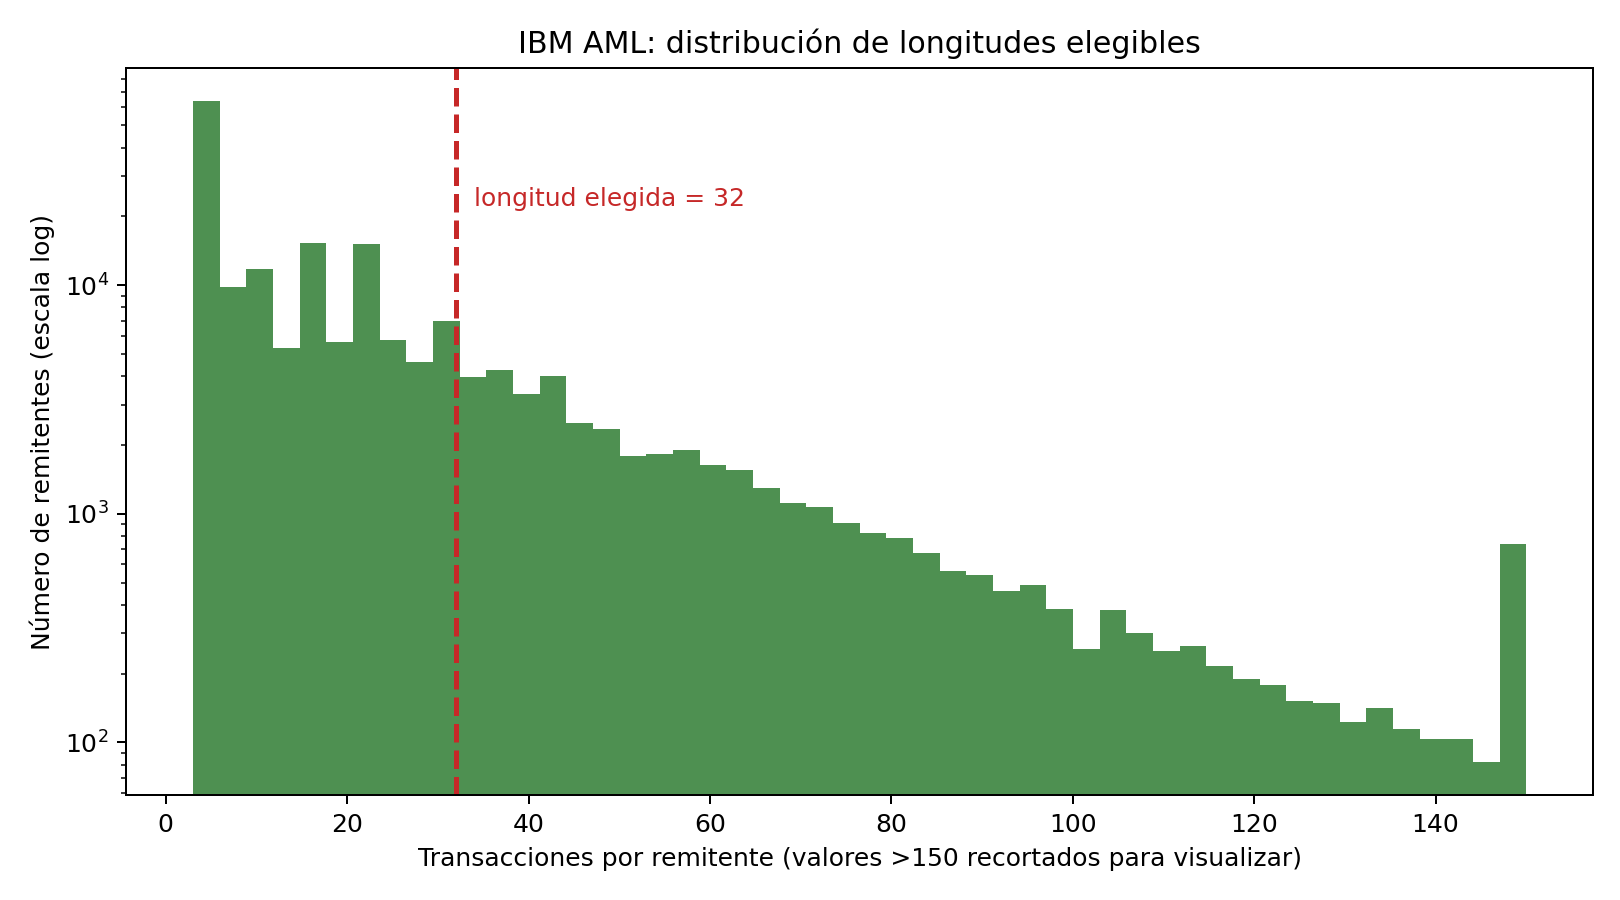

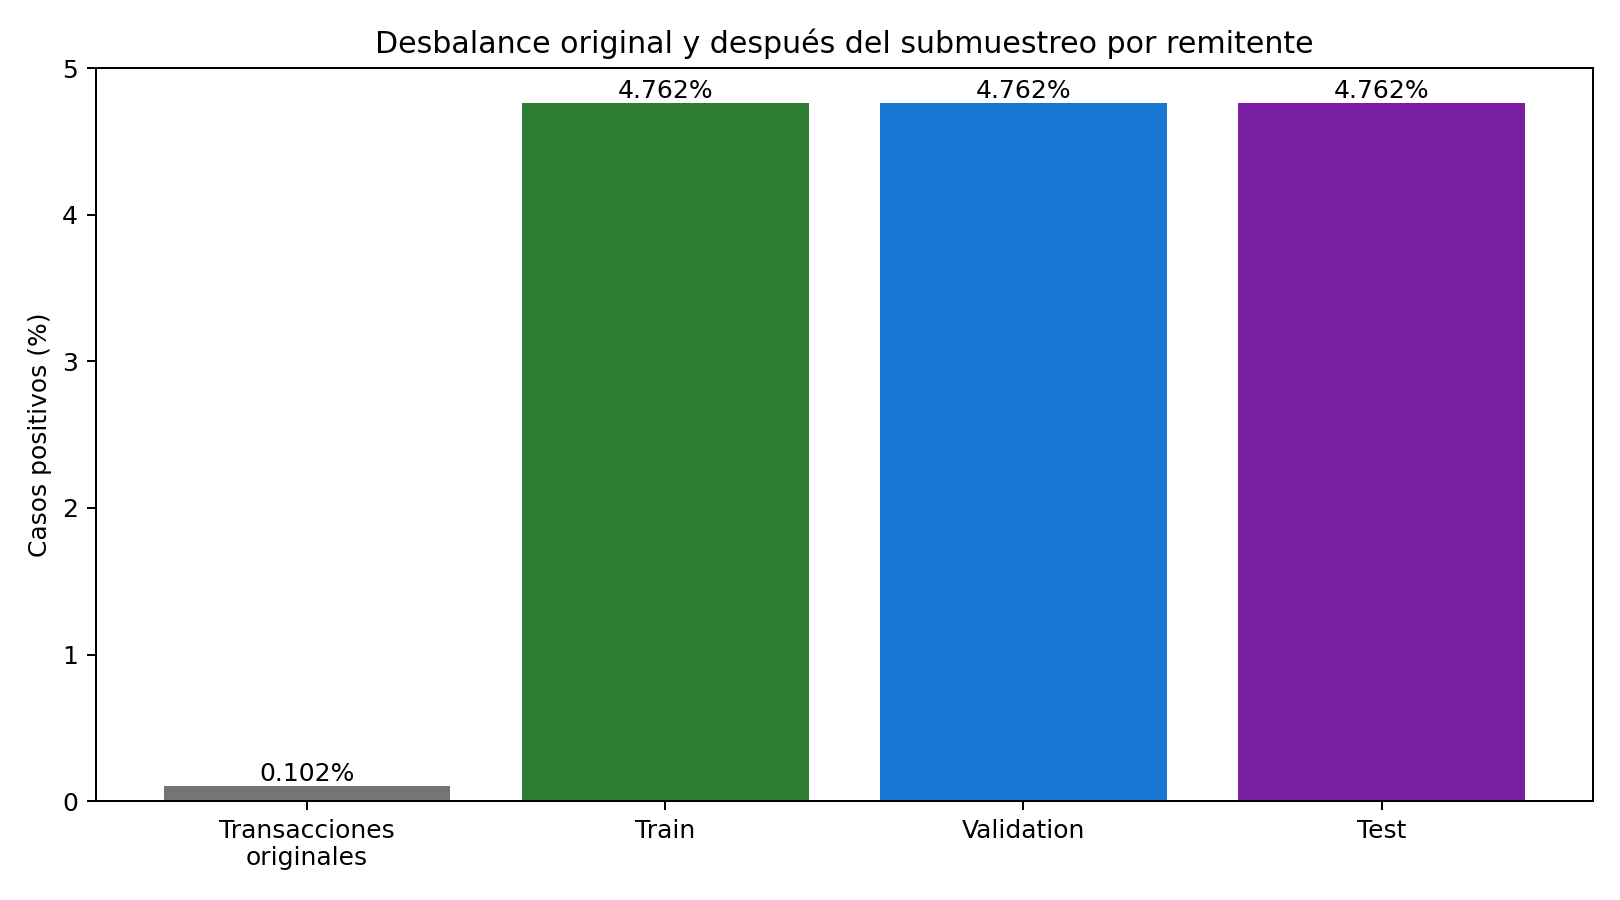

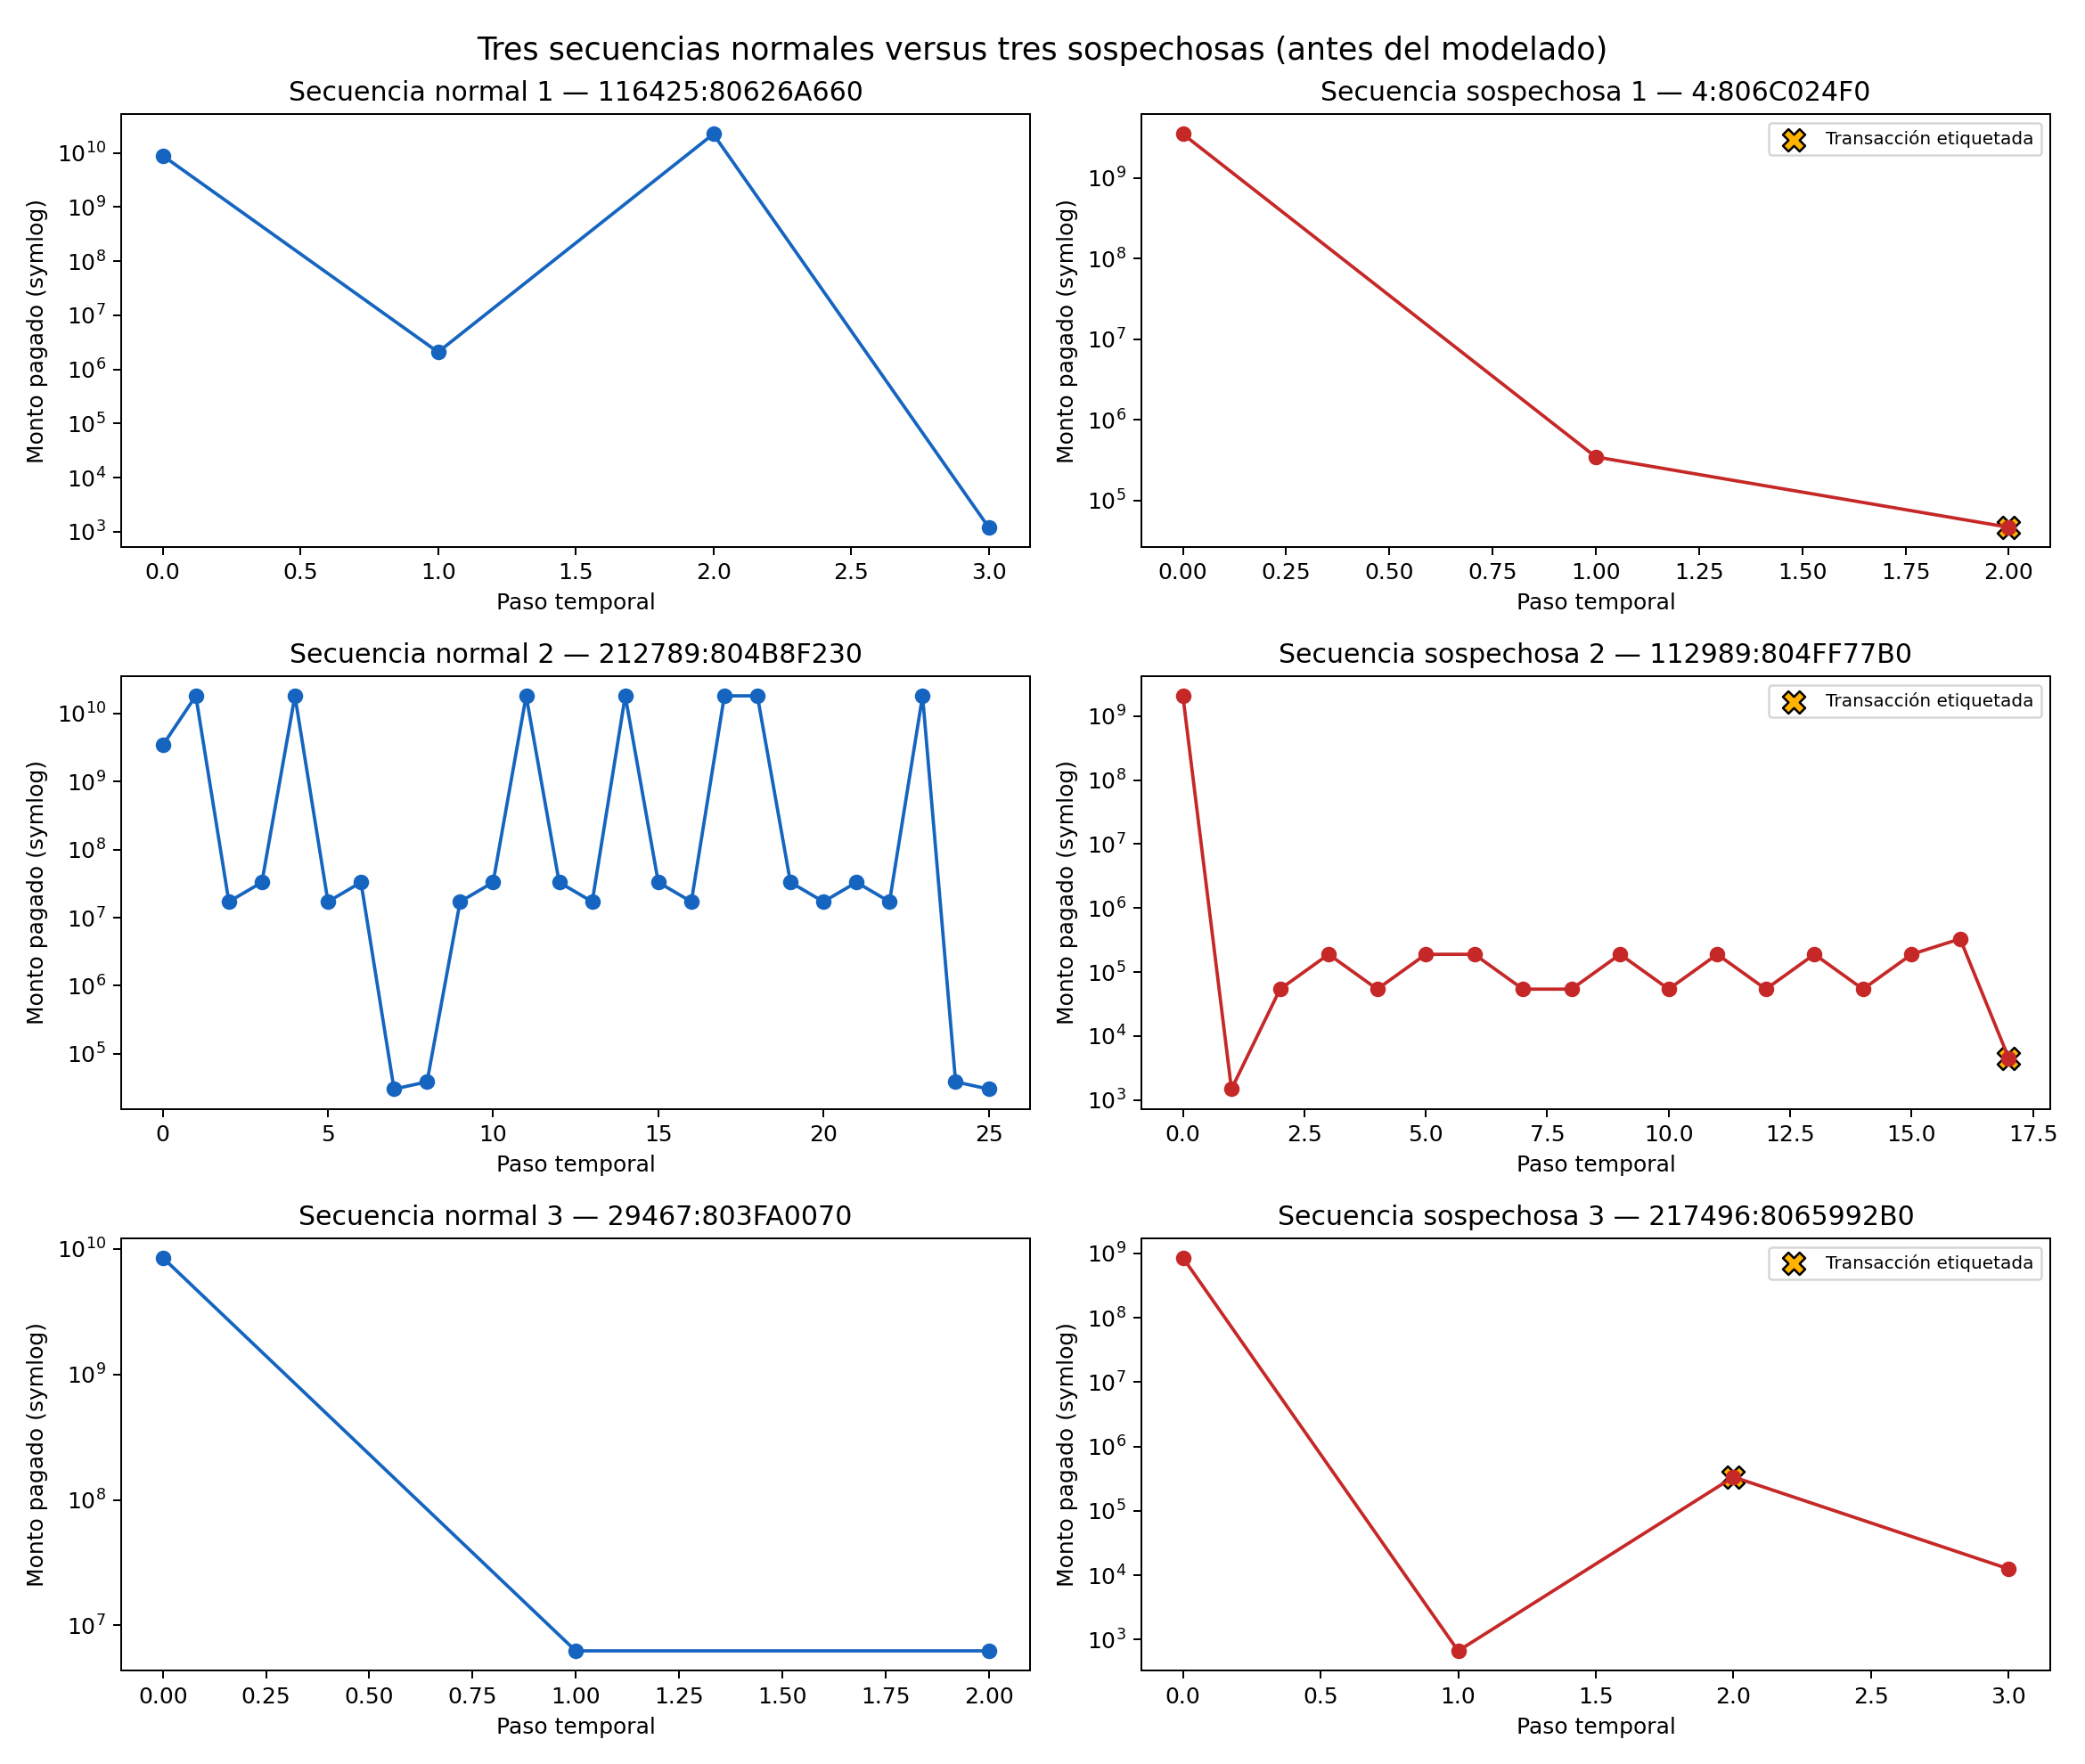

In [5]:
for filename in ["sequence_length_distribution.png", "class_distribution.png", "sequence_examples.png"]:
    display(Image(filename=str(FIGURES / filename)))

### Lectura de las visualizaciones

La distribución confirma una cola larga: longitud 32 conserva completos 77.46%
de los historiales elegibles y evita que unas pocas cuentas con decenas de miles
de operaciones dominen el tensor. La gráfica de clases hace visible que el
submuestreo cambia la prevalencia, pero mantiene veinte negativos por positivo
en cada split.

Los tres pares de secuencias muestran que montos elevados aparecen en ambas
clases y que las operaciones etiquetadas no siempre son las de mayor valor. Por
eso el vector incluye contexto temporal, destino, formato y moneda; usar solo el
monto produciría una regla débil y numerosos falsos positivos.

## 4. Pruebas de integridad y ausencia de leakage

La validación vuelve a cargar los tres NPZ desde disco y comprueba: shapes,
dominio de labels, ausencia de NaN/Inf, unicidad de remitentes, separación entre
splits, coherencia de `lengths` con `mask`, padding en cero, trazabilidad por
timestep y compatibilidad del preprocesador serializado con las 49 features.

In [6]:
from src.data.dataset import load_split
from src.data.splits import assert_disjoint_senders
splits = {name: load_split(ARTIFACTS / f"{name}.npz") for name in ("train", "val", "test")}
assert_disjoint_senders({name: split["sender_id"] for name, split in splits.items()})
feature_names = json.loads((ARTIFACTS / "feature_names.json").read_text(encoding="utf-8"))
with (ARTIFACTS / "scaler.pkl").open("rb") as stream:
    preprocessor = pickle.load(stream)
assert preprocessor.get_feature_names() == feature_names
checks = pd.DataFrame({name: {
    "X": str(split["X"].shape),
    "positivos": int(split["y"].sum()),
    "negativos": int((split["y"] == 0).sum()),
    "NaN_Inf": int((~np.isfinite(split["X"])).sum()),
    "remitentes_unicos": len(np.unique(split["sender_id"])),
} for name, split in splits.items()}).T
display(checks)
print("OK: shapes, labels, NaN/Inf, padding, round-trip, scaler y leakage")

,X,positivos,negativos,NaN_Inf,remitentes_unicos
train,"(40551, 32, 49)",1931,38620,0,40551
val,"(8673, 32, 49)",413,8260,0,8673
test,"(8694, 32, 49)",414,8280,0,8694


OK: shapes, labels, NaN/Inf, padding, round-trip, scaler y leakage


## 5. Archivos producidos y contrato de uso

- `train.npz`, `val.npz`, `test.npz`: tensores, labels, remitentes, longitudes,
  máscaras y trazabilidad.
- `scaler.pkl` y `feature_names.json`: transformación ajustada con TRAIN y orden
  exacto de las 49 features.
- `metadata.json`: configuración, definición de labels, estadísticas y criterio
  de split.
- `val_context.csv.gz` y `test_context.csv.gz`: transacciones legibles asociadas
  a cada timestep para análisis de atención.
- `sender_splits.csv.gz`: asignación reproducible de identidades.

Los consumidores deben cargar los NPZ con `src.data.dataset.load_split`, respetar
`mask` y consultar `metadata.json` en lugar de fijar dimensiones manualmente.